# Descouvemont Example 2: coupled $n$-$p$ $J=1^+$ scattering

This notebook reconstructs Descouvemont's two-channel neutron-proton benchmark: the $^3S_1$-$^3D_1$ coupled system in the $J=1^+$ partial wave.

We will:

1. inspect the Reid soft-core triplet potential pieces,
2. compile the coupled-channel solver on the Appendix B energy grid,
3. compare the extracted eigenphases against the paper,
4. extract a small coupled-channel mixing angle from the $S$-matrix, and
5. finish with a dense energy scan plot (tagged `skip-benchmark` in the automated notebook run).


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

import lax as lm
from lax._descouvemont_utils import (
    np_j1_channels,
    reid_np_j1_potential,
    reid_soft_core_triplet_components,
)

NP_J1_ENERGIES = np.array([12.0, 24.0, 36.0, 48.0], dtype=np.float64)
APPENDIX_PHASE_11 = np.array([1.4258, 1.1052, 0.90182, 0.74900], dtype=np.float64)
APPENDIX_PHASE_22 = np.array([-0.049358, -0.11506, -0.17002, -0.21469], dtype=np.float64)
APPENDIX_ETA_12 = np.array([0.064110, 0.082470, 0.097677, 0.11440], dtype=np.float64)
CHANNELS = np_j1_channels()
CHANNEL_RADIUS = 8.0
BASIS_SIZE = 75


## Reid soft-core potential pieces

The coupled benchmark combines a central triplet term, a tensor term that mixes the $S$ and $D$ channels, and a spin-orbit term that only affects the $D$-wave diagonal block.

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_189856/2596546312.py:16: SyntaxWarning: invalid escape sequence '\l'
  axes[1].plot(r_plot, v_sd, label='$^3S_1 \leftrightarrow ^3D_1$')


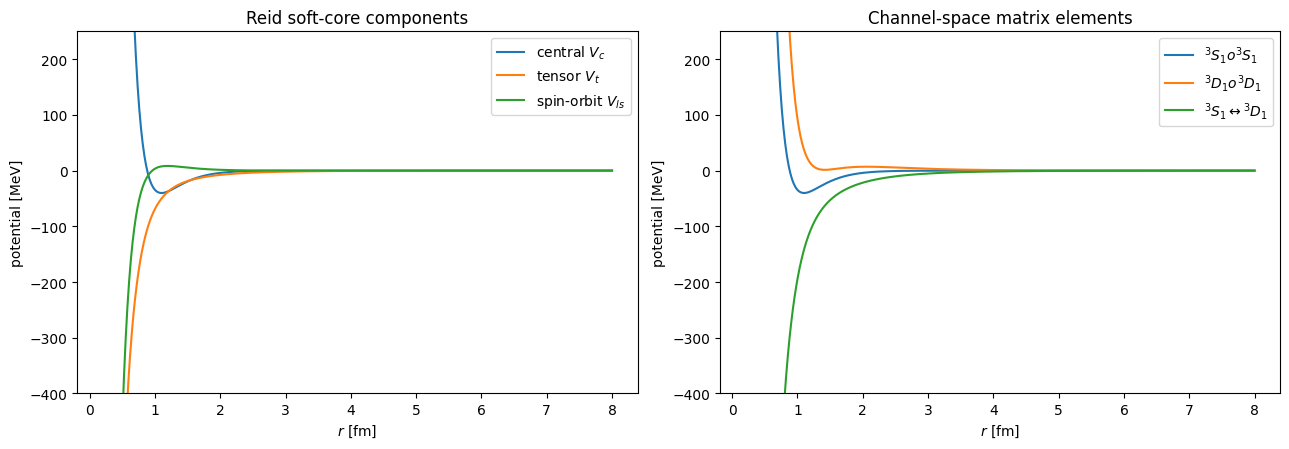

In [2]:
r_plot = np.linspace(0.2, 8.0, 600)
v_c, v_t, v_ls = [np.asarray(values) for values in reid_soft_core_triplet_components(r_plot)]
v_ss = v_c
v_dd = v_c - 2.0 * v_t - 3.0 * v_ls
v_sd = 2.0 * np.sqrt(2.0) * v_t

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(r_plot, v_c, label='central $V_c$')
axes[0].plot(r_plot, v_t, label='tensor $V_t$')
axes[0].plot(r_plot, v_ls, label='spin-orbit $V_{ls}$')
axes[0].set(xlabel='$r$ [fm]', ylabel='potential [MeV]', title='Reid soft-core components', ylim=(-400, 250))
axes[0].legend()

axes[1].plot(r_plot, v_ss, label='$^3S_1 \to ^3S_1$')
axes[1].plot(r_plot, v_dd, label='$^3D_1 \to ^3D_1$')
axes[1].plot(r_plot, v_sd, label='$^3S_1 \leftrightarrow ^3D_1$')
axes[1].set(xlabel='$r$ [fm]', ylabel='potential [MeV]', title='Channel-space matrix elements', ylim=(-400, 250))
axes[1].legend()
plt.tight_layout()


## Appendix B energy grid

The paper tabulates two phase-shift columns at 12, 24, 36, and 48 MeV. With the new `coupled_channel_parameters_from_S()` utility, we can extract the ordered coupled-channel eigenphases directly from the computed $S$-matrix and compare them to the published values.

<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_189856/407017566.py:28: SyntaxWarning: invalid escape sequence '\d'
  axes[0].plot(NP_J1_ENERGIES, appendix.phase_11, 'o--', label='Appendix B $\delta_{11}$')
/tmp/ipykernel_189856/407017566.py:29: SyntaxWarning: invalid escape sequence '\d'
  axes[0].plot(NP_J1_ENERGIES, appendix.phase_22, 'o--', label='Appendix B $\delta_{22}$')
/tmp/ipykernel_189856/407017566.py:37: SyntaxWarning: invalid escape sequence '\e'
  axes[1].plot(NP_J1_ENERGIES, appendix.eta_12, 'x--', label='Appendix B $\eta_{12}$')


E =   12 MeV  phase_1 = +1.425912  phase_2 = -0.049456  mixing = +1.570796
E =   24 MeV  phase_1 = +1.105871  phase_2 = -0.115686  mixing = +1.549140
E =   36 MeV  phase_1 = +0.903118  phase_2 = -0.171321  mixing = +1.440537
E =   48 MeV  phase_1 = +0.751277  phase_2 = -0.216964  mixing = +1.515397


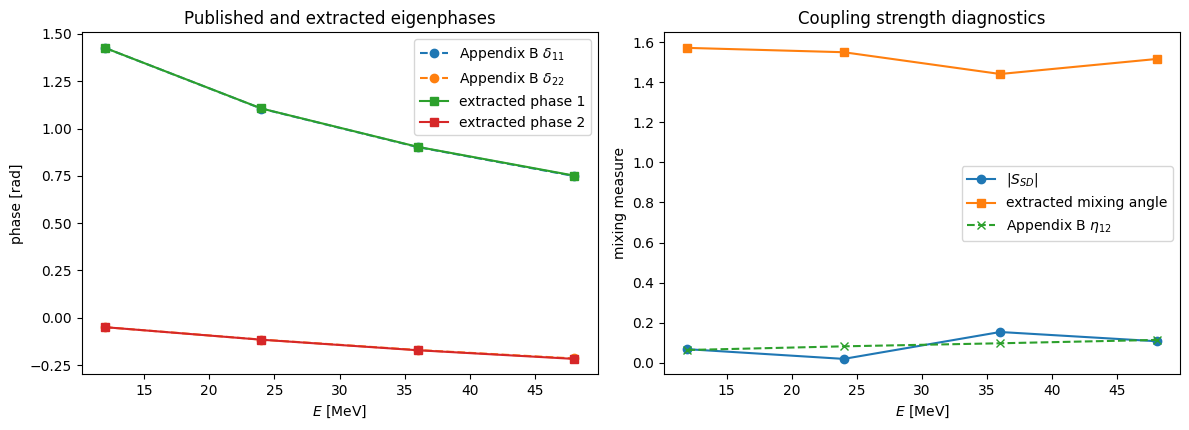

In [3]:
solver = lm.compile(
    mesh=lm.MeshSpec('legendre', 'x', n=BASIS_SIZE, scale=CHANNEL_RADIUS),
    channels=CHANNELS,
    operators=('T+L', '1/r^2'),
    solvers=('spectrum', 'smatrix'),
    energies=NP_J1_ENERGIES,
    method='eigh',
)
potential = lm.assemble_local(solver.mesh, reid_np_j1_potential, n_channels=2)
spectrum = solver.spectrum(potential)
smatrices = np.asarray(solver.smatrix(spectrum))

phase_11 = []
phase_22 = []
mixing = []
for smatrix in smatrices:
    params = lm.spectral.coupled_channel_parameters_from_S(smatrix)
    phase_11.append(float(np.asarray(params.phase_2)))
    phase_22.append(float(np.asarray(params.phase_1)))
    mixing.append(float(np.asarray(params.mixing_angle)))

phase_11 = np.asarray(phase_11)
phase_22 = np.asarray(phase_22)
mixing = np.asarray(mixing)
appendix_phase_11 = APPENDIX_PHASE_11
appendix_phase_22 = APPENDIX_PHASE_22
appendix_eta_12 = APPENDIX_ETA_12

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].plot(NP_J1_ENERGIES, appendix_phase_11, 'o--', label='Appendix B $\delta_{11}$')
axes[0].plot(NP_J1_ENERGIES, appendix_phase_22, 'o--', label='Appendix B $\delta_{22}$')
axes[0].plot(NP_J1_ENERGIES, phase_11, 's-', label='extracted phase 1')
axes[0].plot(NP_J1_ENERGIES, phase_22, 's-', label='extracted phase 2')
axes[0].set(xlabel='$E$ [MeV]', ylabel='phase [rad]', title='Published and extracted eigenphases')
axes[0].legend()

axes[1].plot(NP_J1_ENERGIES, np.abs(smatrices[:, 0, 1]), 'o-', label='$|S_{SD}|$')
axes[1].plot(NP_J1_ENERGIES, np.abs(mixing), 's-', label='extracted mixing angle')
axes[1].plot(NP_J1_ENERGIES, appendix_eta_12, 'x--', label='Appendix B $\eta_{12}$')
axes[1].set(xlabel='$E$ [MeV]', ylabel='mixing measure', title='Coupling strength diagnostics')
axes[1].legend()
plt.tight_layout()

for energy, d11, d22, eps in zip(NP_J1_ENERGIES, phase_11, phase_22, mixing, strict=True):
    print(f'E = {energy:4.0f} MeV  phase_1 = {d11:+.6f}  phase_2 = {d22:+.6f}  mixing = {eps:+.6f}')


## Dense energy scan

These final cells use a finer energy grid to visualize the extracted coupled-channel parameters across the whole low-energy region. They are tagged `skip-benchmark` so the automated notebook run only checks the lighter diagnostic cells above.

In [4]:
%%time
scan_energies = np.linspace(4.0, 60.0, 160)
scan_solver = lm.compile(
    mesh=lm.MeshSpec('legendre', 'x', n=BASIS_SIZE, scale=CHANNEL_RADIUS),
    channels=CHANNELS,
    operators=('T+L', '1/r^2'),
    solvers=('spectrum', 'smatrix'),
    energies=scan_energies,
    method='eigh',
)
scan_potential = lm.assemble_local(scan_solver.mesh, reid_np_j1_potential, n_channels=2)
scan_smatrices = np.asarray(scan_solver.smatrix(scan_solver.spectrum(scan_potential)))


CPU times: user 3.13 s, sys: 30.5 ms, total: 3.16 s
Wall time: 699 ms


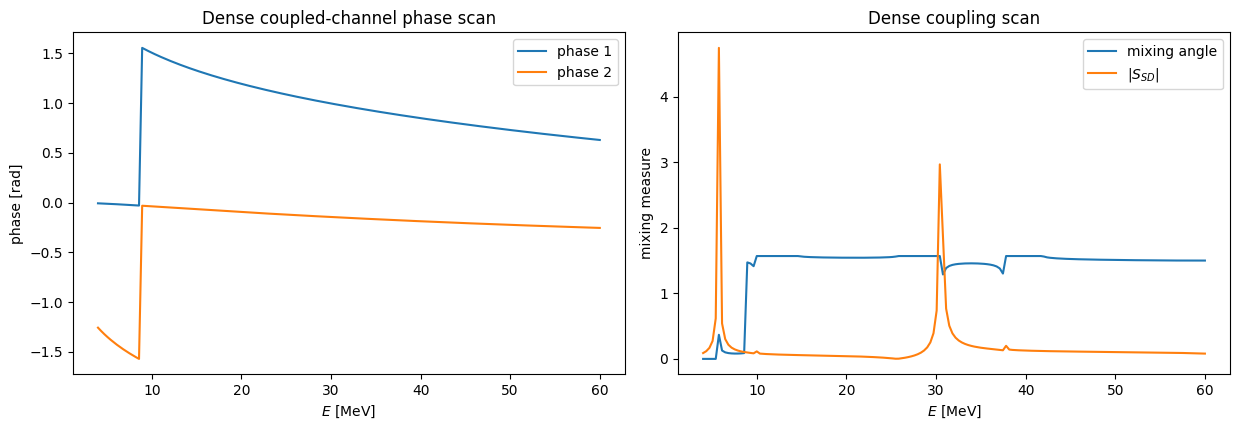

In [5]:
scan_phase_11 = []
scan_phase_22 = []
scan_mixing = []
for smatrix in scan_smatrices:
    params = lm.spectral.coupled_channel_parameters_from_S(smatrix)
    scan_phase_11.append(float(np.asarray(params.phase_2)))
    scan_phase_22.append(float(np.asarray(params.phase_1)))
    scan_mixing.append(float(np.asarray(params.mixing_angle)))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].plot(scan_energies, scan_phase_11, label='phase 1')
axes[0].plot(scan_energies, scan_phase_22, label='phase 2')
axes[0].set(xlabel='$E$ [MeV]', ylabel='phase [rad]', title='Dense coupled-channel phase scan')
axes[0].legend()

axes[1].plot(scan_energies, np.abs(scan_mixing), label='mixing angle')
axes[1].plot(scan_energies, np.abs(scan_smatrices[:, 0, 1]), label='$|S_{SD}|$')
axes[1].set(xlabel='$E$ [MeV]', ylabel='mixing measure', title='Dense coupling scan')
axes[1].legend()
plt.tight_layout()
